In [1]:
import tempfile
from collections.abc import Mapping
from pathlib import Path
from typing import Any, cast

from datamaite import load_ic
from datasets import Dataset
from datasets import load_dataset as hf_load
from numpy.typing import NDArray

# Download MNIST test split, keep the first 4 000 images (reference + incoming)
mnist_test = cast(Dataset, hf_load("ylecun/mnist", split="test")).select(range(4000))

# Materialize as an ImageFolder tree: <root>/<label>/<seq>.png. The zero-padded
# sequence number lets us recover the original download order after reload,
# since datamaite's huggingface_vision loader groups samples by class folder.
mnist_root = Path(tempfile.mkdtemp(prefix="dataeval_flow_mnist_"))
for seq, example in enumerate(mnist_test):
    label_dir = mnist_root / str(example["label"])
    label_dir.mkdir(parents=True, exist_ok=True)
    example["image"].save(label_dir / f"{seq:05d}.png")

mnist_maite_raw = load_ic(mnist_root, dataset_format="huggingface_vision")
_order = sorted(range(len(mnist_maite_raw)), key=lambda i: int(Path(mnist_maite_raw.samples[i].image_id).stem))


class OrderedView:
    """Presents *dataset* through a fixed list of source indices.

    datamaite's ``huggingface_vision`` loader groups samples by class folder
    for a deterministic layout, discarding upload order. We recover it via
    ``_order`` (built from the sequence number embedded in each file name) so
    the rest of this tutorial can rely on "index i is the i-th downloaded
    image" — used below to simulate progressive degradation over "time" and
    to slice out the incoming split.
    """

    def __init__(self, dataset: Any, indices: list[int]) -> None:
        self._dataset = dataset
        self._indices = indices

    def __len__(self) -> int:
        return len(self._indices)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        return self._dataset[self._indices[index]]

    @property
    def metadata(self) -> Any:
        return self._dataset.metadata


# Reference: all 4 000 images, restored to original download order
mnist_maite = OrderedView(mnist_maite_raw, _order)

print(f"Loaded {len(mnist_maite)} MNIST images via datamaite (huggingface_vision)")
print(f"Sample shape: image={mnist_maite[0][0].shape}, label={mnist_maite[0][1]}")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating train split:  52%|█████▎    | 31500/60000 [00:00<00:00, 313070.06 examples/s]

Generating train split: 100%|██████████| 60000/60000 [00:00<00:00, 343395.72 examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 315807.61 examples/s]

Loaded 4000 MNIST images via datamaite (huggingface_vision)
Sample shape: image=(3, 28, 28), label=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [2]:
import numpy as np
from PIL import Image, ImageFilter


class DegradedDataset:
    """Wraps a MAITE dataset and applies progressive Gaussian blur to selected classes.

    Parameters
    ----------
    dataset
        A MAITE-compatible dataset returning (image, target, metadata) tuples,
        with images as CHW uint8 arrays (datamaite's native image format).
    degraded_classes
        Set of class labels to apply blur to.
    max_blur_radius
        Maximum blur radius applied to the last sample.
    """

    def __init__(
        self,
        dataset: Any,
        degraded_classes: set[int],
        max_blur_radius: float = 3.0,
    ) -> None:
        self._dataset = dataset
        self._degraded_classes = degraded_classes
        self.max_blur_radius: float = max_blur_radius

    def __len__(self) -> int:
        return len(self._dataset)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, metadata = self._dataset[index]
        t = np.asarray(target)
        label = int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)

        if label in self._degraded_classes:
            # Blur increases linearly with index — simulates progressive degradation
            progress = index / max(len(self) - 1, 1)
            radius = self.max_blur_radius * progress

            if radius > 0.1:  # skip negligible blur
                chw = np.asarray(image)
                hwc = np.transpose(chw, (1, 2, 0))  # CHW -> HWC
                img_pil = Image.fromarray(hwc, mode="RGB").filter(ImageFilter.GaussianBlur(radius=radius))
                image = np.transpose(np.array(img_pil, dtype=chw.dtype), (2, 0, 1))  # back to CHW

        return image, target, metadata

In [3]:

# Wrap the incoming slice with degradation for classes 1, 4, 7
incoming_maite = OrderedView(mnist_maite_raw, _order[2000:4000])
incoming_dataset = DegradedDataset(
    incoming_maite,
    degraded_classes={1, 4, 7},
    max_blur_radius=3.0,
)

print(f"Reference: {len(mnist_maite)} total images (will select first 2000)")
print(f"Incoming:  {len(incoming_dataset)} images (classes 1,4,7 progressively blurred)")

Reference: 4000 total images (will select first 2000)
Incoming:  2000 images (classes 1,4,7 progressively blurred)


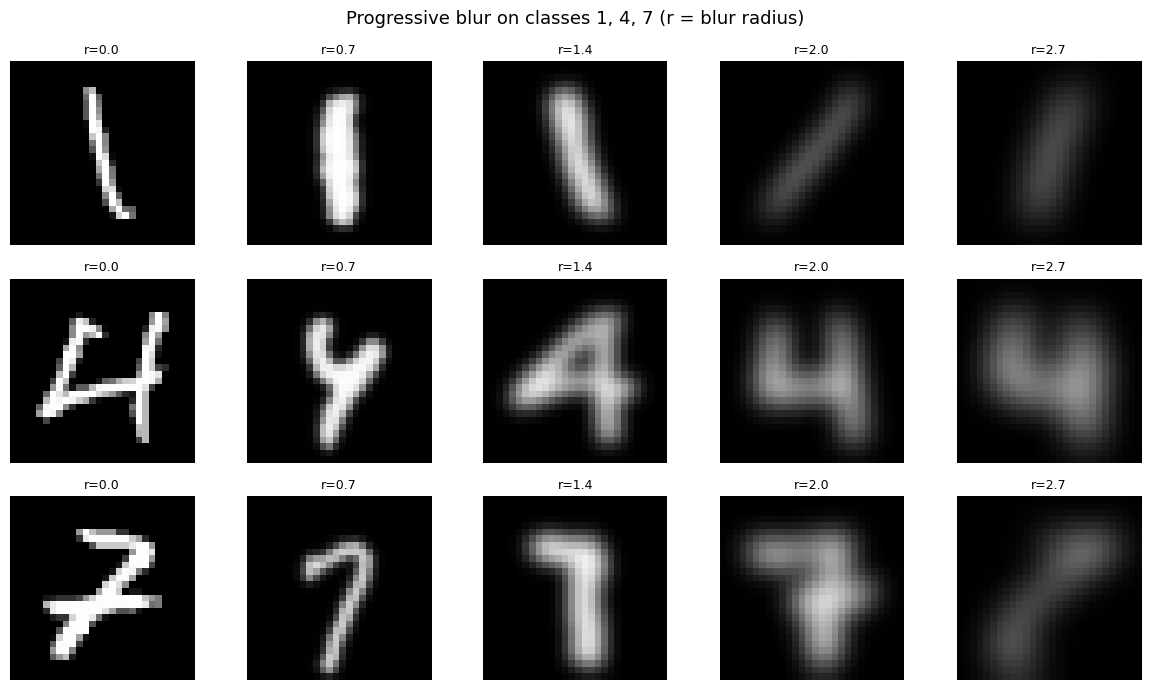

In [4]:
import matplotlib.pyplot as plt

degraded_classes = [1, 4, 7]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(len(degraded_classes), len(positions), figsize=(12, 7))

for row, cls in enumerate(degraded_classes):
    for col, frac in enumerate(positions):
        start = int(frac * len(incoming_dataset) * 0.9)
        for i in range(start, len(incoming_dataset)):
            img, target, _ = incoming_dataset[i]
            t = np.asarray(target)
            label = int(np.argmax(t)) if t.ndim == 1 and t.size > 1 else int(t)
            if label == cls:
                img_arr = np.transpose(np.asarray(img), (1, 2, 0))  # CHW -> HWC
                axes[row, col].imshow(img_arr)
                radius = incoming_dataset.max_blur_radius * (i / max(len(incoming_dataset) - 1, 1))
                axes[row, col].set_title(f"r={radius:.1f}", fontsize=9)
                break
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"Digit {cls}", fontsize=11, rotation=0, labelpad=40)

fig.suptitle("Progressive blur on classes 1, 4, 7 (r = blur radius)", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
from dataeval_flow.config import (
    DatasetProtocolConfig,
    DriftMonitoringTaskConfig,
    DriftMonitoringWorkflowConfig,
    FlattenExtractorConfig,
    PipelineConfig,
    SourceConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.drift.params import ChunkingConfig, DriftDetectorKNeighbors, DriftHealthThresholds

# --- Datasets (in-memory via DatasetProtocolConfig) ---
ref_config = DatasetProtocolConfig(
    name="reference",
    format="maite",
    dataset=mnist_maite,  # full 4k — view will subset it
)

incoming_config = DatasetProtocolConfig(
    name="incoming",
    format="maite",
    dataset=incoming_dataset,
)

# --- Views ---
# Use Indices to select the first 2000 images as the reference baseline
ref_view = ViewConfig(
    name="ref-first-2k",
    operations=[ViewOperation(type="Indices", params={"indices": list(range(2000))})],
)

# --- Sources ---
ref_source_config = SourceConfig(name="reference_2k", dataset="reference", view="ref-first-2k")
inc_source_config = SourceConfig(name="incoming_2k", dataset="incoming")

# --- Extractors ---
extractor_config = FlattenExtractorConfig(
    name="flatten",
    batch_size=64,
)

# --- Workflows ---
drift_workflow_config = DriftMonitoringWorkflowConfig(
    name="overall-drift",
    detectors=[
        DriftDetectorKNeighbors(k=10, chunking=ChunkingConfig(chunk_count=5, threshold_multiplier=1.5)),
    ],
    health_thresholds=DriftHealthThresholds(
        chunk_drift_pct_warning=15.0,
        consecutive_chunks_warning=2,
    ),
)

# --- Phase 1: Overall drift with chunking (no classwise) ---
overall_task = DriftMonitoringTaskConfig(
    name="mnist-overall-drift",
    workflow="overall-drift",
    sources=["reference_2k", "incoming_2k"],
    extractor="flatten",
)

overall_config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    views=[ref_view],
    sources=[ref_source_config, inc_source_config],
    extractors=[extractor_config],
    workflows=[drift_workflow_config],
    tasks=[overall_task],
)

In [6]:
overall_result = run_task(overall_task, overall_config, cache_dir=Path("./cache"))

In [7]:
print(overall_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 2000 ITEMS.
  Timestamp:    2026-07-28T15:09:29.714768+00:00
  Duration:     0.54s
  Source:       reference_2k (reference[ref-first-2k])
                incoming_2k (incoming)
  Model:        flatten (flatten)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (chunk_count=5, z=1.5) ..................................   [!!]

  Health: 1 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (CHUNK_COUNT=5, Z=1.5)
  3/5 chunks drifted (60%) | max consecutive: 2

  Chunk         Distance                                  Status
  -----------  ---------  ------------------------------  ------
  [0:399]      2651.7163  █████████████████████████████░  ok
  [400:799]    2597.1975  ████████████████████████████░░  DRIFT
  [800:1199]   2600.6331  ████████████████████████████░░  DRIFT
  [1200:1599]  2616.3579  ████████████████████████████░░  ok
  [1600:1999]  2707.3245  █

In [8]:
from dataeval_flow.workflows.drift.params import DriftDetectorMMD, DriftDetectorUnivariate

classwise_task = DriftMonitoringTaskConfig(
    name="mnist-classwise-drift",
    workflow="classwise-drift",
    sources=["reference_2k", "incoming_2k"],
    extractor="flatten",
)

classwise_config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    views=[ref_view],
    sources=[ref_source_config, inc_source_config],
    extractors=[extractor_config],
    workflows=[
        DriftMonitoringWorkflowConfig(
            name="classwise-drift",
            detectors=[
                DriftDetectorMMD(n_permutations=100, classwise=True),
                DriftDetectorUnivariate(test="cvm", classwise=True),
            ],
            health_thresholds=DriftHealthThresholds(
                classwise_any_drift_is_warning=True,
            ),
        ),
    ],
    tasks=[classwise_task],
)

In [9]:
classwise_result = run_task(classwise_task, classwise_config, cache_dir=Path("./cache"))

In [10]:
print(classwise_result.report())


  DRIFT MONITORING COMPLETE. REFERENCE: 2000 ITEMS, TEST: 2000 ITEMS.
  Timestamp:    2026-07-28T15:10:01.288879+00:00
  Duration:     31.55s
  Source:       reference_2k (reference[ref-first-2k])
                incoming_2k (incoming)
  Model:        flatten (flatten)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  MMD (classwise=True) ............................ 3/10 classes drifted  [!!]
  CVM Univariate (classwise=True) ................. 3/10 classes drifted  [!!]

  Health: 2 warning(s) [!!] — review flagged findings

  MMD (CLASSWISE=TRUE)                                      3/10 classes drifted
  Classes drifted: 1, 4, 7

  Class  Distance    PVal                                  Status
  -----  --------  ------  ------------------------------  ------
  0       -0.0010    0.74  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  ok
  1        0.1825    0.00  ██████████████████████████████  DRIFT
  2        0.0006    0.21  ░░░░░░░░░░░░░░░░░░

In [11]:
import polars as pl

pl.Config.set_tbl_hide_dataframe_shape(True)

raw = classwise_result.data.raw

# Overall results (from the classwise run)
print("── Overall Drift ──")
for method, det_result in raw.detectors.items():
    status = "DRIFT" if det_result["drifted"] else "ok"
    print(f"  {method}: {status} (distance={det_result['distance']:.4f})")
print()

# Classwise results
if raw.classwise:
    print("── Classwise Drift ──")
    for cw in raw.classwise:
        print(f"\n  Detector: {cw['detector']}")
        rows = [
            {
                "class": r["class_name"],
                "drifted": r["drifted"],
                "distance": round(r["distance"], 4),
                "p_val": round(r["p_val"], 6) if r.get("p_val") is not None else None,  # type:ignore
            }
            for r in cw["rows"]
        ]
        df = pl.DataFrame(rows)
        print(df)

── Overall Drift ──
  mmd: DRIFT (distance=0.0043)
  univariate: DRIFT (distance=5.1401)

── Classwise Drift ──

  Detector: MMD (classwise=True)
┌───────┬─────────┬──────────┬───────┐
│ class ┆ drifted ┆ distance ┆ p_val │
│ ---   ┆ ---     ┆ ---      ┆ ---   │
│ str   ┆ bool    ┆ f64      ┆ f64   │
╞═══════╪═════════╪══════════╪═══════╡
│ 0     ┆ false   ┆ -0.001   ┆ 0.74  │
│ 1     ┆ true    ┆ 0.1825   ┆ 0.0   │
│ 2     ┆ false   ┆ 0.0006   ┆ 0.21  │
│ 3     ┆ false   ┆ -0.0007  ┆ 0.74  │
│ 4     ┆ true    ┆ 0.1004   ┆ 0.0   │
│ 5     ┆ false   ┆ 0.0009   ┆ 0.21  │
│ 6     ┆ false   ┆ -0.0013  ┆ 0.85  │
│ 7     ┆ true    ┆ 0.1076   ┆ 0.0   │
│ 8     ┆ false   ┆ -0.0002  ┆ 0.57  │
│ 9     ┆ false   ┆ 0.0008   ┆ 0.21  │
└───────┴─────────┴──────────┴───────┘

  Detector: CVM Univariate (classwise=True)
┌───────┬─────────┬──────────┬──────────┐
│ class ┆ drifted ┆ distance ┆ p_val    │
│ ---   ┆ ---     ┆ ---      ┆ ---      │
│ str   ┆ bool    ┆ f64      ┆ f64      │
╞═══════╪════════

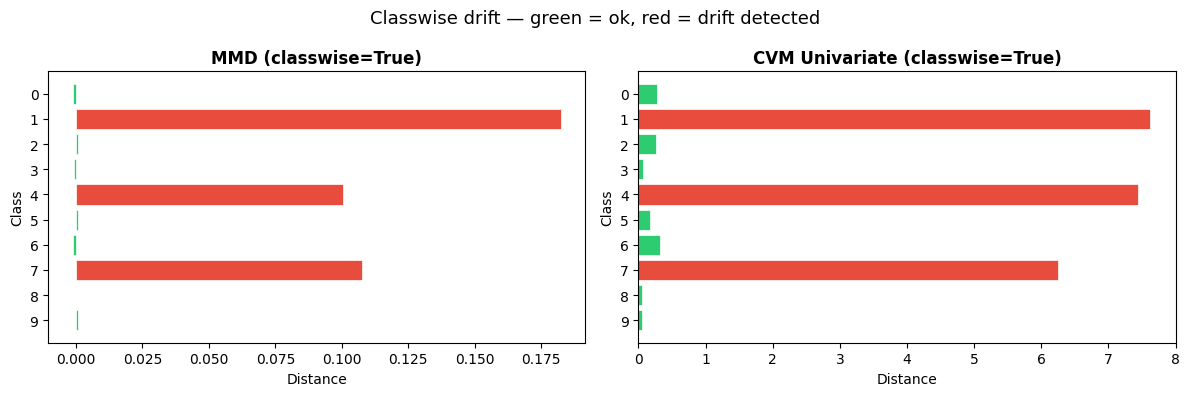

In [12]:
assert raw.classwise is not None  # classwise=True was set on each detector above
detectors = [cw["detector"] for cw in raw.classwise]

fig, axes = plt.subplots(1, len(detectors), figsize=(6 * len(detectors), 4))
if len(detectors) == 1:
    axes = [axes]

for ax, cw in zip(axes, raw.classwise, strict=True):
    class_names = [r["class_name"] for r in cw["rows"]]
    distances = [r["distance"] for r in cw["rows"]]
    drifted = [r["drifted"] for r in cw["rows"]]
    colors = ["#e74c3c" if d else "#2ecc71" for d in drifted]

    ax.barh(class_names, distances, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Class")
    ax.set_title(cw["detector"], fontsize=12, fontweight="bold")
    ax.invert_yaxis()

fig.suptitle("Classwise drift — green = ok, red = drift detected", fontsize=13)
plt.tight_layout()
plt.show()